In [1]:
import numpy as np
from scipy.special import legendre
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
np.random.seed(20)
import pandas as pd
import sys
import os
import numpy as np
from itertools import product
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

In [2]:
# Generate synthetic multi-fidelity data
np.random.seed(42)
n_lf = 309  # Low-fidelity samples
n_hf = 10   # High-fidelity samples

# Low-fidelity model (simpler polynomial)
u_lf = np.random.uniform(-1, 1, (n_lf, 1))
y_lf = 2 * u_lf + 0.5 * u_lf**2 + np.random.normal(0, 0.1, size=(n_lf, 1))
print(u_lf)
# High-fidelity model (more complex)
u_hf = np.random.uniform(-1, 1, (n_hf, 1))
y_hf = 2 * u_hf + 0.5 * u_hf**2 - 0.1 * u_hf**3 + np.random.normal(0, 0.01, size=(n_hf, 1))


[[-0.25091976]
 [ 0.90142861]
 [ 0.46398788]
 [ 0.19731697]
 [-0.68796272]
 [-0.68801096]
 [-0.88383278]
 [ 0.73235229]
 [ 0.20223002]
 [ 0.41614516]
 [-0.95883101]
 [ 0.9398197 ]
 [ 0.66488528]
 [-0.57532178]
 [-0.63635007]
 [-0.63319098]
 [-0.39151551]
 [ 0.04951286]
 [-0.13610996]
 [-0.41754172]
 [ 0.22370579]
 [-0.72101228]
 [-0.4157107 ]
 [-0.26727631]
 [-0.08786003]
 [ 0.57035192]
 [-0.60065244]
 [ 0.02846888]
 [ 0.18482914]
 [-0.90709917]
 [ 0.2150897 ]
 [-0.65895175]
 [-0.86989681]
 [ 0.89777107]
 [ 0.93126407]
 [ 0.6167947 ]
 [-0.39077246]
 [-0.80465577]
 [ 0.36846605]
 [-0.11969501]
 [-0.75592353]
 [-0.00964618]
 [-0.93122296]
 [ 0.8186408 ]
 [-0.48244004]
 [ 0.32504457]
 [-0.37657785]
 [ 0.04013604]
 [ 0.09342056]
 [-0.63029109]
 [ 0.93916926]
 [ 0.55026565]
 [ 0.87899788]
 [ 0.7896547 ]
 [ 0.19579996]
 [ 0.84374847]
 [-0.823015  ]
 [-0.60803428]
 [-0.90954542]
 [-0.34933934]
 [-0.22264542]
 [-0.45730194]
 [ 0.65747502]
 [-0.28649335]
 [-0.43813098]
 [ 0.08539217]
 [-0.71815

In [3]:
version = 'vpce1.1'
file_in=f'Ge77_rates_CNP_{version}.csv'
if not os.path.exists(f'out/{version}'):
   os.makedirs(f'out/{version}')
   

# Set parameter name/x_labels -> needs to be consistent with data input file
x_labels=['Radius[cm]','Thickness[cm]','NPanels', 'Theta[deg]', 'Length[cm]']
x_labels_out = ['Radius [cm]','Thickness [cm]','NPanels', 'Angle [deg]', 'Length [cm]']

y_err_label_cnp = 'Ge-77_CNP_err'
y_label_sim = 'rGe77[nuc/(kg*yr)]'

# Set parameter boundaries
xmin=[0,0,0,0,0]
xmax=[265,20,360,90,150]

# Set parameter boundaries for aquisition function
xlow=[90,2,4,0,1]
xhigh=[250,15,360,90,150]

# Assign costs
low_fidelity_cost = 1.
high_fidelity_cost = 2000.
n_fidelities = 2
# Set a fixed point in space for drawings
x_fixed = [160, 2, 40, 45, 20]
# number of sigma for error band drawing on prediction
factor=1.

# Get LF noise from file
#with open(f'in/{file_in}') as f:
#    first_line = f.readline()
#LF_noise=np.round(float(first_line.split(' +')[0].split('= ')[1]),3)
LF_noise = 0.028
# Get HF and LF data samples from file

data=pd.read_csv(f'in/{file_in}')
#data=data[[f'Mode', x_labels[0], x_labels[1], x_labels[2], x_labels[3], x_labels[4],y_label_cnp,y_err_label_cnp,y_label_sim]]


In [4]:
x_lf, x_hf, y_lf, y_hf = ([],[],[],[])
row_h=data.index[data['Mode'] == 1]
row_l=data.index[data['Mode'] == 0]

x_hf = data.loc[data['Mode']==1.][x_labels].to_numpy()
y_hf = data.loc[data['Mode']==1.][y_label_sim].to_numpy()

x_lf = data.loc[data['Mode']==0.][x_labels].to_numpy()
y_lf = data.loc[data['Mode']==0.][ y_label_sim].to_numpy()


In [5]:
data=pd.read_csv("./in/hf_validation_data_v1.2.csv")
x_test = data.loc[data['Mode']==1.][x_labels].to_numpy()
y_true_test = data.loc[data['Mode']==1.][y_label_sim].to_numpy()

In [6]:
# Define multivariate Legendre polynomial basis
def multivariate_legendre_basis(order, x):
    """Generate multivariate Legendre polynomial basis up to a given order."""
    n_samples, n_features = x.shape
    # Generate all combinations of polynomial degrees
    degrees = product(range(order + 1), repeat=n_features)
    basis = []
    for degree in degrees:
        # Compute the product of univariate Legendre polynomials
        term = np.ones(n_samples)
        for i, d in enumerate(degree):
            term *= np.polynomial.legendre.Legendre.basis(d)(x[:, i])
        basis.append(term)
    return np.vstack(basis).T

In [ ]:
# Basis generation
order = 6  # Polynomial order
phi_lf = multivariate_legendre_basis(order, x_lf)  # Low-fidelity PCE basis
phi_hf = multivariate_legendre_basis(order, x_hf)  # High-fidelity PCE basis

# Step 1: Train Low-Fidelity Model
reg_lf = LinearRegression()
reg_lf.fit(phi_lf, y_lf)
beta_lf = reg_lf.coef_.flatten()

# Step 2: Train High-Fidelity Correction Model
y_lf_hf_pred = phi_hf @ beta_lf  # LF prediction at HF points
delta_hf = y_hf.flatten() - y_lf_hf_pred  # High-fidelity correction

reg_hf = LinearRegression()
reg_hf.fit(phi_hf, delta_hf)
beta_hf = reg_hf.coef_.flatten()

# Step 3: Multi-Fidelity Prediction
def multi_fidelity_pce_predict(x_test, beta_lf, beta_hf, order):
    """Predict output using multi-fidelity PCE."""
    phi_test = multivariate_legendre_basis(order, x_test)
    y_lf_pred = phi_test @ beta_lf
    y_hf_correction = phi_test @ beta_hf
    return y_lf_pred + y_hf_correction

# Test points
x_test = np.random.uniform(-1, 1, (100, 5))  # Test data (5D)
y_pred_mf = multi_fidelity_pce_predict(x_test, beta_lf, beta_hf, order)

# Evaluation metrics
print("Low-fidelity coefficients:", beta_lf)
print("High-fidelity correction coefficients:", beta_hf)

Low-fidelity coefficients: [ 1.99320232e-16 -5.34577328e-19  6.15408876e-18 ... -5.91883683e-22
  9.16854128e-23 -5.01587807e-24]
High-fidelity correction coefficients: [-7.09591055e-21 -8.71286193e-31 -4.16177211e-30 ...  4.11036943e-21
  1.11922279e-20  1.75033483e-20]


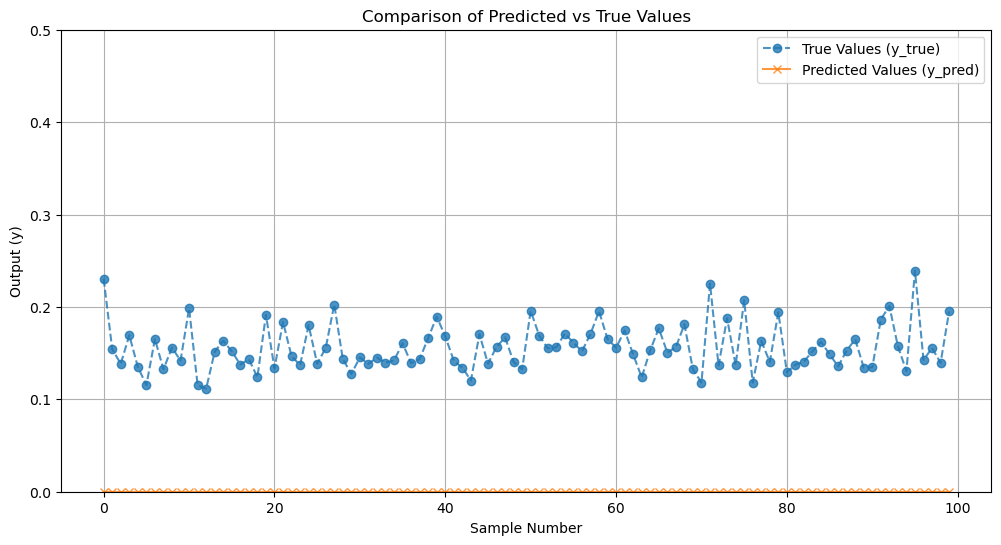

In [8]:

# Generate predictions for the test set

y_pred_test = multi_fidelity_pce_predict(x_test, beta_lf, beta_hf, order)

# Plot predicted vs true values
plt.figure(figsize=(12, 6))
plt.plot(y_true_test, label="True Values (y_true)", linestyle="--", marker="o", alpha=0.8)
plt.plot(y_pred_test, label="Predicted Values (y_pred)", linestyle="-", marker="x", alpha=0.8)
plt.xlabel("Sample Number")
plt.ylabel("Output (y)")
plt.title("Comparison of Predicted vs True Values")
plt.legend()
plt.ylim(0.,0.5)
plt.grid(True)
plt.show()